# 📈 OFI Feature Construction with PCA
This notebook computes Order Flow Imbalance (OFI) features from order book data, applies PCA, and visualizes the results.

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("first_25000_rows.csv")
df.head()


,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,ask_sz_08,bid_ct_08,ask_ct_08,bid_px_09,ask_px_09,bid_sz_09,ask_sz_09,bid_ct_09,ask_ct_09,symbol
0,2024-10-21T11:54:29.221230963Z,2024-10-21T11:54:29.221064336Z,10,2,38,C,B,1,233.62,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
1,2024-10-21T11:54:29.223936626Z,2024-10-21T11:54:29.223769812Z,10,2,38,A,B,0,233.67,2,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
2,2024-10-21T11:54:29.225196809Z,2024-10-21T11:54:29.225030400Z,10,2,38,A,B,0,233.67,3,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
3,2024-10-21T11:54:29.712600612Z,2024-10-21T11:54:29.712434212Z,10,2,38,A,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL
4,2024-10-21T11:54:29.764839221Z,2024-10-21T11:54:29.764673165Z,10,2,38,C,B,2,233.52,200,...,155,1,7,233.25,234.13,55,400,2,1,AAPL


### 🧮 OFI Calculation Function

In [2]:
def calculate_ofi_level(df, level_str):
    bid_price = df[f'bid_px_{level_str}']
    bid_size = df[f'bid_sz_{level_str}']
    ask_price = df[f'ask_px_{level_str}']
    ask_size = df[f'ask_sz_{level_str}']

    bid_flow = (bid_price > bid_price.shift(1)) * bid_size + \
               (bid_price == bid_price.shift(1)) * (bid_size - bid_size.shift(1)) - \
               (bid_price < bid_price.shift(1)) * bid_size

    ask_flow = -1 * ((ask_price > ask_price.shift(1)) * ask_size + \
                     (ask_price == ask_price.shift(1)) * (ask_size - ask_size.shift(1)) - \
                     (ask_price < ask_price.shift(1)) * ask_size)

    return (bid_flow + ask_flow).fillna(0)


### 🔁 Compute OFI for Depth Levels 00 to 09

In [3]:
for i in range(10):
    level_str = f'0{i}'
    df[f'OFI_level_{i+1}'] = calculate_ofi_level(df, level_str)
df[[f'OFI_level_{i+1}' for i in range(10)]].head()


,OFI_level_1,OFI_level_2,OFI_level_3,OFI_level_4,OFI_level_5,OFI_level_6,OFI_level_7,OFI_level_8,OFI_level_9,OFI_level_10
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,-200.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 📊 Standardize and Apply PCA

In [4]:
ofi_columns = [f'OFI_level_{i+1}' for i in range(10)]
ofi_data = df[ofi_columns].dropna()

scaler = StandardScaler()
ofi_scaled = scaler.fit_transform(ofi_data)

pca = PCA(n_components=1)
ofi_integrated = pca.fit_transform(ofi_scaled)

df['OFI_integrated'] = np.nan
df.loc[ofi_data.index, 'OFI_integrated'] = ofi_integrated.flatten()
df[['OFI_integrated']].head()


,OFI_integrated
0,-0.045486
1,-0.042987
2,-0.041737
3,0.151471
4,-0.242443


### 📈 Plot: PCA Variance Explained

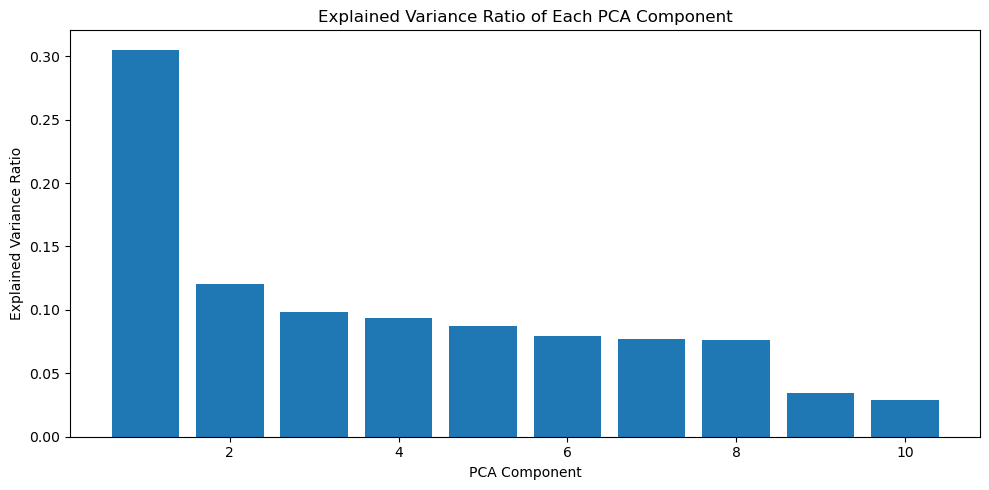

In [5]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), PCA().fit(ofi_scaled).explained_variance_ratio_[:10])
plt.title('Explained Variance Ratio of Each PCA Component')
plt.xlabel('PCA Component')
plt.ylabel('Explained Variance Ratio')
plt.tight_layout()
plt.savefig("pca_variance_plot.png")
plt.show()


### 📉 Plot: OFI Level 00 vs Integrated OFI

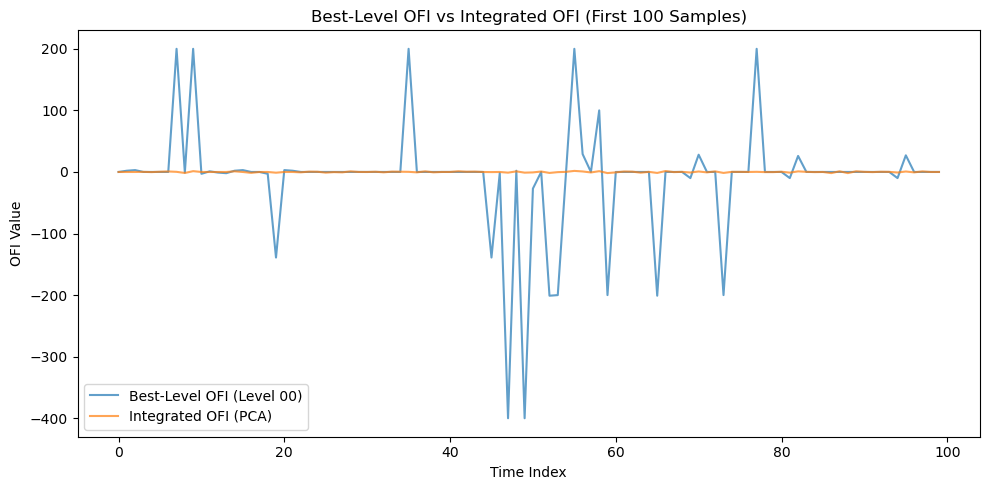

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df['OFI_level_1'][:100], label='Best-Level OFI (Level 00)', alpha=0.7)
plt.plot(df['OFI_integrated'][:100], label='Integrated OFI (PCA)', alpha=0.7)
plt.legend()
plt.title('Best-Level OFI vs Integrated OFI (First 100 Samples)')
plt.xlabel('Time Index')
plt.ylabel('OFI Value')
plt.tight_layout()
plt.savefig("ofi_comparison_plot.png")
plt.show()
